## Imports & Setup

In [36]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
# from xgboost import XGBClassifier
# from lightgbm import LGBMClassifier

# Model Selection & Evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_validate
from sklearn.metrics import accuracy_score, mean_squared_error, classification_report, confusion_matrix, cohen_kappa_score

# SHAP for feature importance
import shap

# For reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)



## Load Dataset

In [37]:
file_path = "pneumonia_survey_dataset_final_begad.csv"
df = pd.read_csv(file_path)

df.head()


,HasChestIndrawing,HasAbnormalBreathingSound,HasCyanosis,BreathingEffort,HasNasalFlaring,FeedingAbility,FeverDuration,FeverLevel,FeverResponse,CoughTime,CoughType,PhlegmStatus,CoughSeverity,RecurrentIssues,HeartCondition,FatigueStatus,CanCompleteMealWithoutStopping,HasWeakCry,HasSevereRunnyNoseWithBreathingDifficulty,Risk_Class
0,Yes,No,No,FastBreathing,No,DifficultyCompleting,From1To3Days,LessThan38,DidNotTakeMedicine,IncreasesNighttime,ProductiveCough,DifficultToExit,Severe,Sometimes,IDontKnow,Yes,EatsNormally,Yes,Yes,Severe Pneumonia
1,Yes,No,No,FastBreathing,Yes,CanComplete,NormalTemperature,LessThan38,ReducedEasily,NoCough,DryCough,NoPhlegm,Mild,Rarely,Yes,Yes,EatsNormally,No,No,High Risk
2,No,No,No,Normal,No,CanComplete,NormalTemperature,NotMeasured,ReducedEasily,IncreasesDaytime,DryCough,EasyToExit,Moderate,Rarely,No,No,EatsNormally,Yes,No,Low Risk
3,No,No,No,Normal,No,CanComplete,NormalTemperature,LessThan38,DidNotTakeMedicine,IncreasesDaytime,DryCough,EasyToExit,Moderate,Rarely,No,No,RefusesCompletely,No,No,Low Risk
4,NotSure,Yes,Yes,LooksExhausted,Yes,DifficultyCompleting,From1To3Days,LessThan38,ReducedEasily,IncreasesNighttime,ProductiveCough,NoPhlegm,Severe,Significantly,IDontKnow,Yes,RefusesCompletely,Yes,Yes,Severe Pneumonia


# Pre-processing

## Data preparation

In [38]:
df = df.rename(columns={
    "CanCompleteMealWithoutStopping": "AppetiteStatus",
    "RecurrentIssues": "RecurrentChestIssues"
})


In [39]:
df["HasChestIndrawing"] = df["HasChestIndrawing"].replace({
    "NotSure": "Not_Sure"
})


In [40]:
boolean_columns = [
    "HasAbnormalBreathingSound",
    "HasNasalFlaring",
    "HasCyanosis",
    "FatigueStatus",
    "HasWeakCry",
    "HasSevereRunnyNoseWithBreathingDifficulty"
]

for col in boolean_columns:
    df[col] = df[col].map({
        "Yes": True,
        "No": False
    }).astype(bool)



In [41]:
print(df[boolean_columns].dtypes)

HasAbnormalBreathingSound                    bool
HasNasalFlaring                              bool
HasCyanosis                                  bool
FatigueStatus                                bool
HasWeakCry                                   bool
HasSevereRunnyNoseWithBreathingDifficulty    bool
dtype: object


In [42]:
df.head()

,HasChestIndrawing,HasAbnormalBreathingSound,HasCyanosis,BreathingEffort,HasNasalFlaring,FeedingAbility,FeverDuration,FeverLevel,FeverResponse,CoughTime,CoughType,PhlegmStatus,CoughSeverity,RecurrentChestIssues,HeartCondition,FatigueStatus,AppetiteStatus,HasWeakCry,HasSevereRunnyNoseWithBreathingDifficulty,Risk_Class
0,Yes,False,False,FastBreathing,False,DifficultyCompleting,From1To3Days,LessThan38,DidNotTakeMedicine,IncreasesNighttime,ProductiveCough,DifficultToExit,Severe,Sometimes,IDontKnow,True,EatsNormally,True,True,Severe Pneumonia
1,Yes,False,False,FastBreathing,True,CanComplete,NormalTemperature,LessThan38,ReducedEasily,NoCough,DryCough,NoPhlegm,Mild,Rarely,Yes,True,EatsNormally,False,False,High Risk
2,No,False,False,Normal,False,CanComplete,NormalTemperature,NotMeasured,ReducedEasily,IncreasesDaytime,DryCough,EasyToExit,Moderate,Rarely,No,False,EatsNormally,True,False,Low Risk
3,No,False,False,Normal,False,CanComplete,NormalTemperature,LessThan38,DidNotTakeMedicine,IncreasesDaytime,DryCough,EasyToExit,Moderate,Rarely,No,False,RefusesCompletely,False,False,Low Risk
4,Not_Sure,True,True,LooksExhausted,True,DifficultyCompleting,From1To3Days,LessThan38,ReducedEasily,IncreasesNighttime,ProductiveCough,NoPhlegm,Severe,Significantly,IDontKnow,True,RefusesCompletely,True,True,Severe Pneumonia


## Remove Duplicates

In [43]:
total_rows = df.shape[0]
duplicate_rows = df.duplicated().sum()

duplicate_percentage = (duplicate_rows / total_rows) * 100

print(f"Total rows: {total_rows}")
print(f"Duplicate rows: {duplicate_rows}")
print(f"Duplicate percentage: {duplicate_percentage:.2f}%")




Total rows: 1000
Duplicate rows: 80
Duplicate percentage: 8.00%


In [44]:
# Remove duplicates
df = df.drop_duplicates().reset_index(drop=True)

print(f"Rows after removing duplicates: {df.shape[0]}")

Rows after removing duplicates: 920


## Feature / Target Split

In [45]:
X = df.drop(columns=["Risk_Class"])
y = df["Risk_Class"]


## Manual Ordinal Encoding (Target)

In [46]:
medical_label_mapping = {
    "Low Risk": 0,
    "Moderate Risk": 1,
    "High Risk": 2,
    "Severe Pneumonia": 3
}

y_encoded = y.map(medical_label_mapping)

# تأكيد إن كل القيم اتعملها Mapping
assert y_encoded.isna().sum() == 0

medical_label_mapping



{'Low Risk': 0, 'Moderate Risk': 1, 'High Risk': 2, 'Severe Pneumonia': 3}

## Train / Test Split

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (736, 19)
Test size: (184, 19)


## Categorical Features Encoding

In [48]:
categorical_features = X.columns.tolist()  # all columns assumed categorical for now

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)


## Visualize Target Distribution

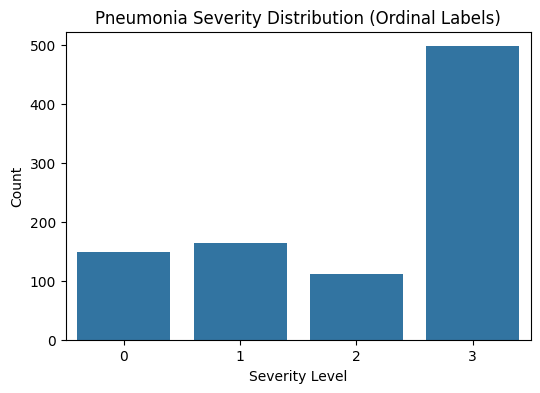

In [49]:
plt.figure(figsize=(6,4))
sns.countplot(x=y_encoded)
plt.title("Pneumonia Severity Distribution (Ordinal Labels)")
plt.xlabel("Severity Level")
plt.ylabel("Count")
plt.show()


# Modeling

## Define Models

In [50]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, multi_class='multinomial', solver='lbfgs'
    ),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    # "XGBoost": XGBClassifier(random_state=RANDOM_STATE, use_label_encoder=False, eval_metric='mlogloss'),
    
}

## Cross-Validation Setup

In [51]:
from sklearn.metrics import make_scorer, cohen_kappa_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "accuracy": "accuracy",
    "mse": "neg_mean_squared_error",
    "kappa": make_scorer(cohen_kappa_score, weights='quadratic')
}


## Cross-Validation (Train Set Only)

In [52]:
cv_results_summary = {}

for model_name, model in models.items():
    
    pipeline = Pipeline(steps=[
        ("preprocessing", preprocessor),
        ("model", model)
    ])
    
    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )
    
    acc = cv_results["test_accuracy"]
    mse = -cv_results["test_mse"]
    
    cv_results_summary[model_name] = {
        "Accuracy per fold": acc,
        "Avg Accuracy": acc.mean(),
        "MSE per fold": mse,
        "Avg MSE": mse.mean()
    }
    
    print("="*60)
    print(f"Model: {model_name}")
    print("Accuracy per fold:", acc)
    print("Average Accuracy:", acc.mean())
    print("MSE per fold:", mse)
    print("Average MSE:", mse.mean())


C:\Users\Maryam Alaa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\Maryam Alaa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\Maryam Alaa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\Maryam Alaa\AppData

Model: Logistic Regression
Accuracy per fold: [0.89864865 0.91156463 0.91836735 0.9047619  0.8707483 ]
Average Accuracy: 0.9008181651038794
MSE per fold: [0.10135135 0.08843537 0.08163265 0.0952381  0.1292517 ]
Average MSE: 0.0991818348961206
Model: Decision Tree
Accuracy per fold: [0.7027027  0.69387755 0.7755102  0.78911565 0.74829932]
Average Accuracy: 0.7419010847582276
MSE per fold: [0.35810811 0.3877551  0.32653061 0.27210884 0.33333333]
Average MSE: 0.3355671998529141
Model: Random Forest
Accuracy per fold: [0.83783784 0.82993197 0.84353741 0.87755102 0.84353741]
Average Accuracy: 0.8464791321934179
MSE per fold: [0.16216216 0.17006803 0.15646259 0.12244898 0.17687075]
Average MSE: 0.1576025004596433
Model: Gradient Boosting
Accuracy per fold: [0.83108108 0.80952381 0.85034014 0.88435374 0.81632653]
Average Accuracy: 0.838325059753631
MSE per fold: [0.16891892 0.23129252 0.17006803 0.11564626 0.18367347]
Average MSE: 0.17391983820555248


## Cross-Validation Summary Table

In [53]:
summary_df = pd.DataFrame({
    model: {
        "Avg Accuracy": cv_results_summary[model]["Avg Accuracy"],
        "Avg MSE": cv_results_summary[model]["Avg MSE"]
    }
    for model in cv_results_summary
}).T

summary_df

,Avg Accuracy,Avg MSE
Logistic Regression,0.900818,0.099182
Decision Tree,0.741901,0.335567
Random Forest,0.846479,0.157603
Gradient Boosting,0.838325,0.173920


## Model Comparison Visualization

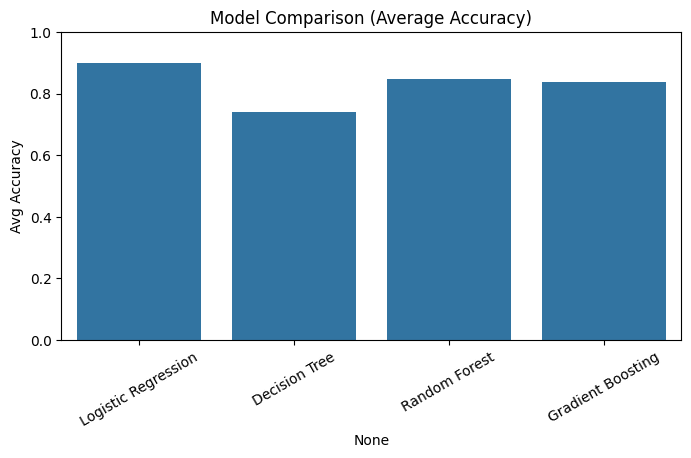

In [54]:

plt.figure(figsize=(8,4))
sns.barplot(x=summary_df.index, y=summary_df["Avg Accuracy"])
plt.title("Model Comparison (Average Accuracy)")
plt.xticks(rotation=30)
plt.ylim(0,1)
plt.show()

##  Tuning Hyperparameters for Logistic Regression

In [55]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, mean_squared_error, classification_report, confusion_matrix, cohen_kappa_score

#  1 – إعداد Pipeline
pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

#  2 – تحديد الـ Hyperparameters للـ Logistic Regression
param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],   # regularization strength
    "model__solver": ["liblinear", "lbfgs"],  # solver options
    "model__penalty": ["l2"]  # لوجيستيك ريجريشن مع multi-class يستخدم L2 غالبًا
}

#  3 – إعداد GridSearchCV
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,   # StratifiedKFold من قبل
    scoring='accuracy',
    n_jobs=-1
)

#  4 – تدريب الـ GridSearch
grid_search.fit(X_train, y_train)

# أفضل الـ hyperparameters
print("Best Params:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)





Best Params: {'model__C': 100, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best CV Accuracy: 0.9361463504320646


## Evaluate on Test Set

In [56]:
#  5 – تقييم على الـ Test Set
best_lr = grid_search.best_estimator_
y_pred = best_lr.predict(X_test)

print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Test Quadratic Weighted Kappa:", cohen_kappa_score(y_test, y_pred, weights='quadratic'))


Test Accuracy: 0.9239130434782609
Test MSE: 0.07608695652173914
Test Quadratic Weighted Kappa: 0.9717593404665849


## Classification Report

In [57]:

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Low Risk", "Moderate Risk", "High Risk", "Severe Pneumonia"]
))



Classification Report:
                  precision    recall  f1-score   support

        Low Risk       0.96      0.90      0.93        30
   Moderate Risk       0.83      0.91      0.87        33
       High Risk       0.75      0.82      0.78        22
Severe Pneumonia       0.99      0.96      0.97        99

        accuracy                           0.92       184
       macro avg       0.88      0.90      0.89       184
    weighted avg       0.93      0.92      0.93       184



## Confusion Matrix (Normalized)

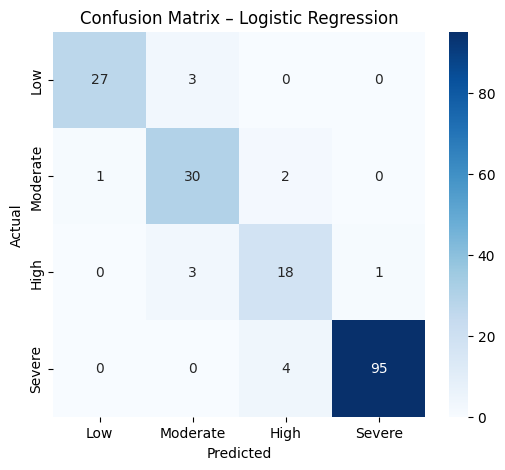

In [58]:


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low", "Moderate", "High", "Severe"],
            yticklabels=["Low", "Moderate", "High", "Severe"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Logistic Regression")
plt.show()

## Feature Importance + SHAP

C:\Users\Maryam Alaa\AppData\Local\Temp\ipykernel_6784\2071556187.py:15: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


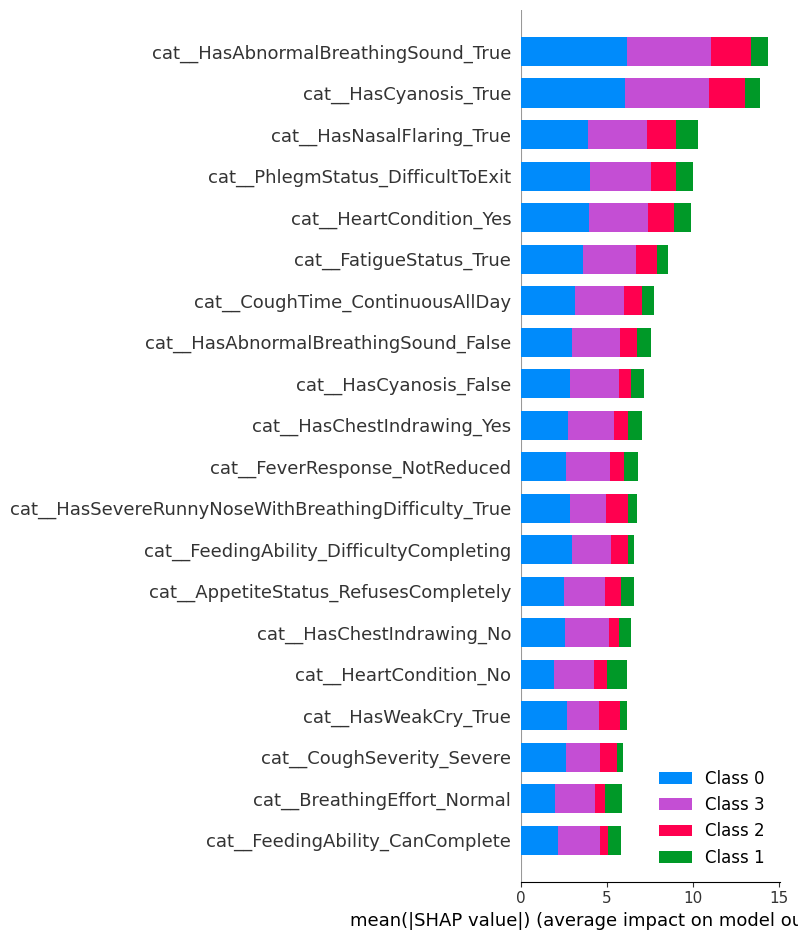

In [59]:
import shap

# خدي أفضل pipeline من GridSearch
best_pipeline = grid_search.best_estimator_

# model + preprocessing
model = best_pipeline.named_steps["model"]
X_encoded = best_pipeline.named_steps["preprocessing"].transform(X_train)

# SHAP explainer للـ Logistic Regression
explainer = shap.LinearExplainer(model, X_encoded)
shap_values = explainer(X_encoded)

# Summary plot
shap.summary_plot(
    shap_values,
    X_encoded,
    feature_names=best_pipeline.named_steps["preprocessing"].get_feature_names_out()
)


## Save 

In [60]:
import joblib

# أفضل pipeline من GridSearch
best_pipeline = grid_search.best_estimator_

# حفظ المودل
joblib.dump(best_pipeline, "servey_model.pkl")



['servey_model.pkl']